In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd "/content/drive/MyDrive/Colab Notebooks"

/content/drive/MyDrive/Colab Notebooks


In [ ]:
"""
... is the place where you need to fill in
"""

import cv2
import numpy as np
import time
from google.colab.patches import cv2_imshow

def resize(src, new_size):
    dst_w, dst_h = new_size  # width and height of the target image
    src_h, src_w = src.shape[:2]  # width and height of the source image
    if src_h == dst_h and src_w == dst_w:
        return src.copy()
    scale_x = float(src_w) / dst_w  # scaling of x
    scale_y = float(src_h) / dst_h  # scaling of y

    # dst is the target image
    dst = np.zeros((dst_h, dst_w), dtype=np.uint8)
    for dst_y in range(dst_h):
        for dst_x in range(dst_w):
            # the corresponding coordinate of the target in the source image P(src_x, src_y)
            src_x = (dst_x + 0.5) * scale_x - 0.5
            src_y = (dst_y + 0.5) * scale_y - 0.5
            # four nearest points of a target point Q11(src_x_1, src_y_1), Q22(src_x_2, src_y_2), Q12(src_x_1, src_y_2), Q21(src_x_2, src_y_1)
            src_x_1 = int(np.floor(src_x))
            src_y_1 = int(np.floor(src_y))
            src_x_2 = min(src_x_1 + 1, src_w - 1)
            src_y_2 = min(src_y_1 + 1, src_h - 1)

            ###########################################################
            """
            Please refer to Page 108 of the slide Topic 2: Intensity Transformation.
            Complete the code of bilinear interpolation
            """
            f_x_y1 = (src_x_2 - src_x)/(src_x_2 - src_x_1) * src[src_y_1, src_x_1]          + (src_x - src_x_1)/(src_x_2 - src_x_1) * src[src_y_1, src_x_2]
            f_x_y2 = (src_x_2 - src_x)/(src_x_2 - src_x_1) * src[src_y_2, src_x_1]          + (src_x - src_x_1)/(src_x_2 - src_x_1) * src[src_y_2, src_x_2]
            dst[dst_y, dst_x] = int((src_y_2 - src_y)/(src_y_2 - src_y_1) * f_x_y1 + (src_y - src_y_1)/(src_y_2 - src_y_1) * f_x_y2 )
            ###########################################################

    return dst



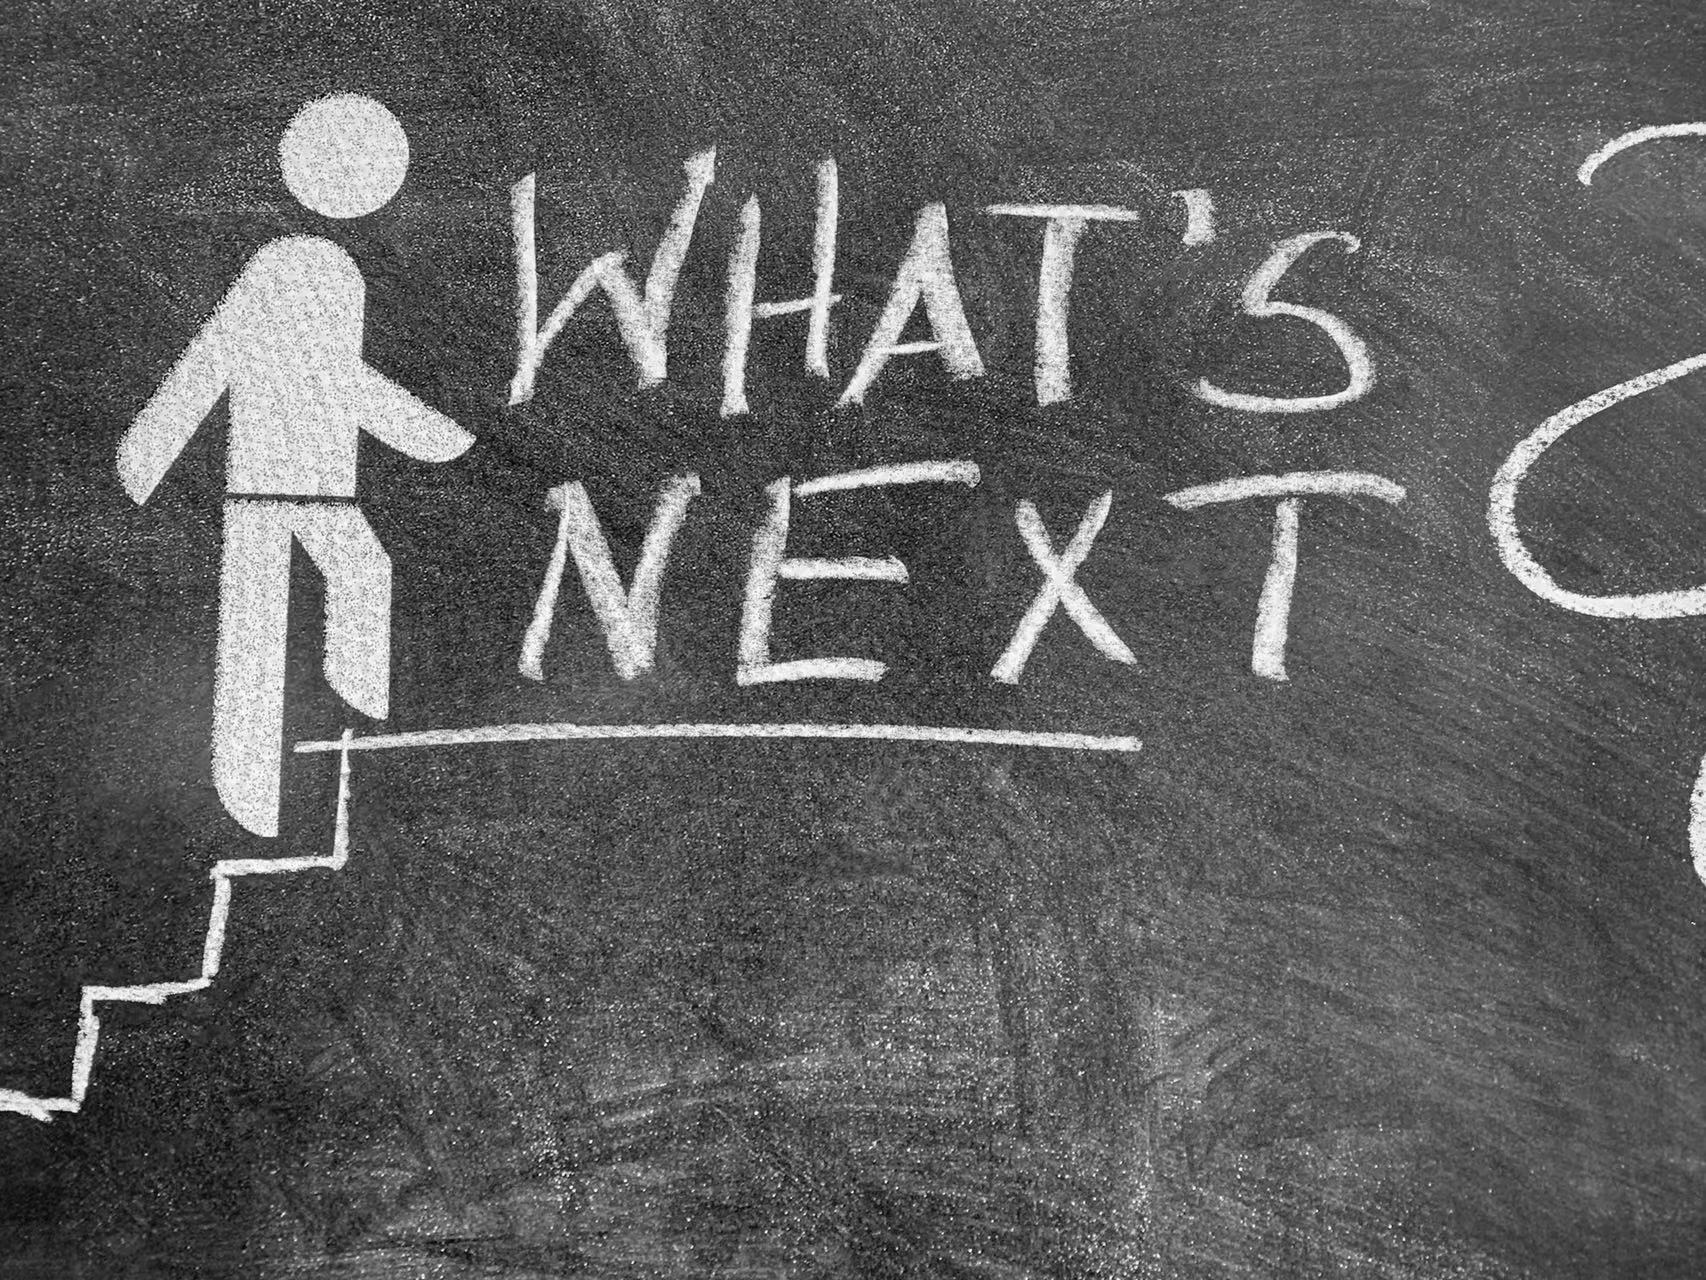

In [17]:
img_in = cv2.imread('test2.jpg', 0)
cv2_imshow(img_in)

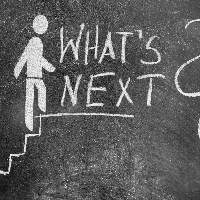

True

In [ ]:

img_out = resize(img_in, (200, 200))
cv2_imshow(img_out)
cv2.imwrite('test2_resized.jpg', img_out)